# Simplified device geolocator
First we import the now cleaned dataset. 

d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
d:\Sources\COM763-Assignment\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  wa

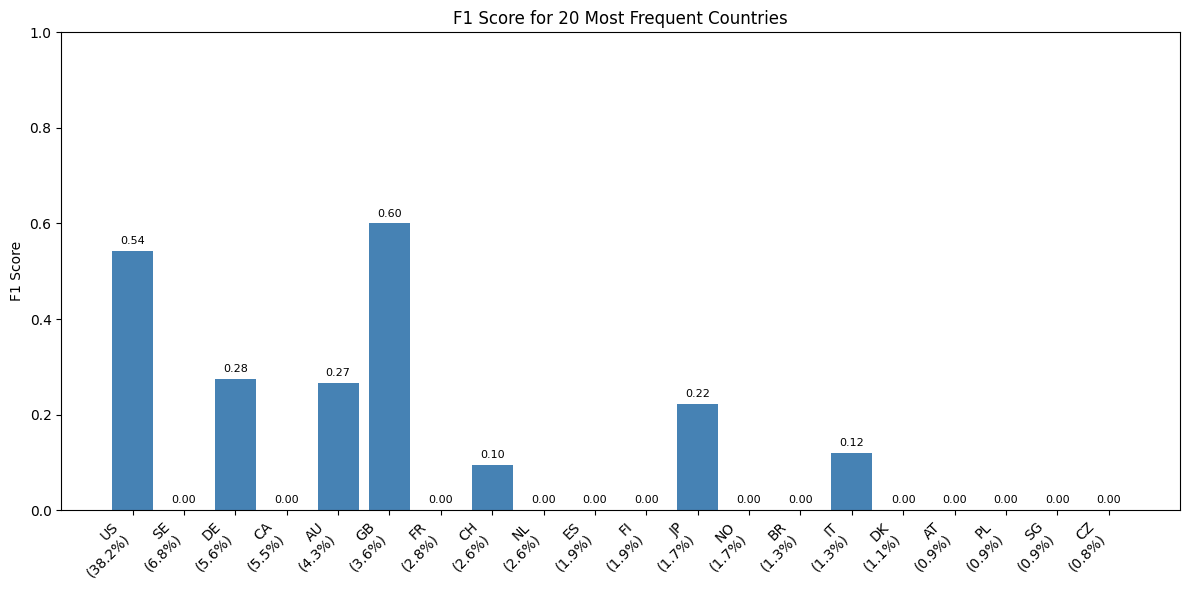

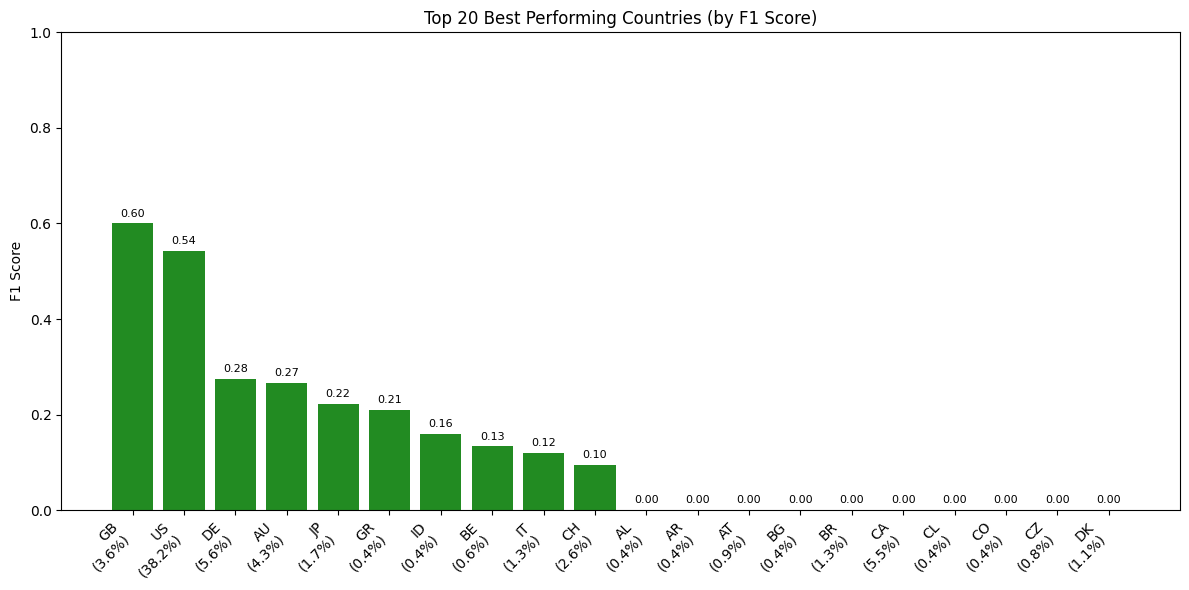

In [2]:
import joblib
from pathlib import Path 
import pandas as pd

from shared import create_best_performing_bar_chart, create_frequency_bar_chart

dataset = pd.read_csv(
    Path("clean_dataset.csv"), 
    skip_blank_lines=True, 
    header=0)

dataset["latency"] = pd.to_numeric(dataset.latency, errors='coerce')
dataset["hops"] = pd.to_numeric(dataset.hops, errors='coerce')

grouped = dataset.groupby(dataset.origin)
test_set = grouped.get_group("Mullvad")

ensemble = joblib.load('geolocation_pipeline.pkl')
prediction = ensemble.predict(test_set[['latency', 'hops']])

create_frequency_bar_chart(test_set, prediction)
create_best_performing_bar_chart(test_set, prediction)